In [1]:
import tensorflow as tf
import pathlib
import matplotlib.pyplot as plt
import os
import numpy as np

"""
1) Buscar as máscaras - OK
2) Carregar e pré-processar as máscaras - OK
3) Criar pipeline para Aumento de Dados - OK
4) Configurar um dataset baseado nas máscaras - OK
5) Formular um treinamento - PENDENTE
6) Visualizar imagens - OK
"""

### 1. Configurar o caminho e criar lista de imagens ###
img_dir = '/media/renato/Data/PIBIC/FinalImage'
img_dir = pathlib.Path(img_dir)
mask_dir = '/media/renato/Data/PIBIC/Results'
mask_dir = pathlib.Path(mask_dir)

# Verificar se o diretório existe
if not os.path.exists(mask_dir):
    raise ValueError(f"Diretório não encontrado: {mask_dir}")

# Função para extrair o número do nome do arquivo
def get_file_number(filepath):
    return int(os.path.basename(filepath).replace('.png', ''))
def get_file_number_mask(filepath):
    return int(os.path.basename(filepath).replace('.npy', ''))

# Verificar se os arquivos existem e converter PosixPath para strings 
mask_files = []
for path in mask_dir.glob('*.npy'):
    if os.path.exists(path):
        mask_files.append(str(path))

image_files = []
for path in img_dir.glob('*.png'):
    if os.path.exists(path):
        image_files.append(str(path))

# Ordenar a lista usando o número do arquivo como chave
image_files = sorted(image_files, key=get_file_number)
mask_files = sorted(mask_files, key=get_file_number_mask)

if len(image_files) != len(mask_files):
    raise ValueError("El número de imágenes y máscaras no coincide")

mask_count = len(mask_files)
print(f"Encontradas {mask_count} máscaras")

# Verificar se temos imagens
if mask_count == 0:
    raise ValueError(f"Nenhuma imagem PNG encontrada em: {mask_dir}")

# Mostrar alguns caminhos de exemplo
print("\nPrimeiros 5 caminhos de máscaras:")
for path in mask_files[:5]:
    print(path)

2025-01-22 15:18:36.236407: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Encontradas 5036 máscaras

Primeiros 5 caminhos de máscaras:
/media/renato/Data/PIBIC/Results/000.npy
/media/renato/Data/PIBIC/Results/001.npy
/media/renato/Data/PIBIC/Results/002.npy
/media/renato/Data/PIBIC/Results/003.npy
/media/renato/Data/PIBIC/Results/004.npy


In [2]:
import numpy as np
mask = np.load(r'/media/renato/Data/PIBIC/Results/000.npy')

In [3]:
mask.shape

(256, 256, 18)

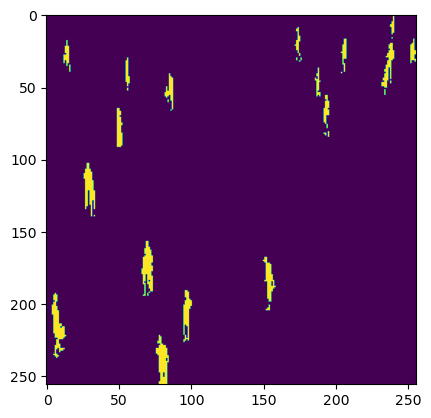

In [8]:
plt.imshow(mask[:,:,16])

In [9]:
def load_and_preprocess_image_mask(image_path, mask_path):
    try:
        # Cargar imagen RGB
        img = tf.io.read_file(image_path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, [256, 256])  # Redimensionar al tamaño de la máscara para 256,256,3
        img = tf.cast(img, tf.float32) / 255.0  # Normalizar la imagen

        # Cargar máscara desde archivo .npy
        mask = np.load(mask_path.numpy().decode())  # Leer la máscara
        mask = tf.convert_to_tensor(mask, dtype=tf.float32)  # Convertir a tensor de TensorFlow

        return img, mask
    except Exception as e:
        print(f"Error al procesar imagen/máscara {image_path}, {mask_path}: {str(e)}")
        raise

## Función para aplicar Data Augmentation considerando las máscaras como matrices de múltiples capas
def augment_image_mask(image, mask):
    # Aplicar aumentos de datos aleatorios a la imagen
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, 0.8, 1.2)

    # Aplicar aumentos de datos compatibles a la máscara (sin modificaciones de intensidad)
    mask = tf.image.flip_left_right(mask)
    mask = tf.image.flip_up_down(mask)

    # Rotaciones en múltiplos de 90 grados (para imagen y máscara por igual)
    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)  # 0, 90, 180, 270 grados
    image = tf.image.rot90(image, k=k)

    # Aplicar rotación a cada canal de la máscara agregando una dimensión adicional temporalmente antes de rotar
    mask = tf.transpose(mask, perm=[2, 0, 1])  # Poner canales al frente (18, 512, 910)
    mask = tf.expand_dims(mask, axis=-1)  # Añadir dimensión extra (18, 512, 910, 1)
    mask = tf.map_fn(lambda x: tf.image.rot90(x, k=k), mask)  # Rotar cada capa
    mask = tf.squeeze(mask, axis=-1)  # Eliminar la dimensión extra
    mask = tf.transpose(mask, perm=[1, 2, 0])  # Devolver a forma original (512, 910, 18)

    return image, mask

# Convertir listas de rutas en TensorFlow Dataset
def process_path(image_path, mask_path):
    img, mask = tf.py_function(load_and_preprocess_image_mask, [image_path, mask_path], [tf.float32, tf.float32])
    img.set_shape((256, 256, 3))  # Establecer tamaño esperado de imagen
    mask.set_shape((256, 256, 18))  # Establecer tamaño esperado de máscara
    return img, mask

# Crear dataset desde las listas de imágenes y máscaras
train_dataset = tf.data.Dataset.from_tensor_slices((image_files, mask_files))
train_dataset = train_dataset.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

# Aplicar data augmentation
train_dataset = train_dataset.map(lambda img, mask: augment_image_mask(img, mask), num_parallel_calls=tf.data.AUTOTUNE)

# Configurar el dataset
BUFFER_SIZE = 100
BATCH_SIZE = 32

train_dataset = (
    train_dataset
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Inspeccionar el dataset
for img, mask in train_dataset.take(1):
    print(f"Imagen batch: {img.shape}")  # Esperado: (batch_size, 256, 256, 3)
    print(f"Máscara batch: {mask.shape}")  # Esperado: (batch_size, 256, 256, 18)

Imagen batch: (32, 256, 256, 3)
Máscara batch: (32, 256, 256, 18)


2025-01-22 15:20:35.307302: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
